In [48]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

import cartopy.crs as ccrs

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [49]:
ssplist = ["126","245","370","585"]

ssplistplot = ["hist","126","245","370","585"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1950,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1960,2025]
baselineera_obs = [1940,1960]

inputlength = 10
outputavgtime = 5

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

device = 'mps'


data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [50]:
imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)

In [51]:
obsnull = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsaccuracy = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

obsfirstpositive = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

allbaselines = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
baseline_percentile = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

for ilat,lat in enumerate(AllObs.output_lat):

    for ilon,lon in enumerate(AllObs.output_lon):

        metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed*.json"
        filelist = glob.glob(metricsout)

        if len(filelist)!=0:
            print('models exist, proceeding')

            bestseeds = helpers.get_best_files(filelist,n_best)
            obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)

            obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
            obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
            obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)
            obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

            print(bestseeds)
            obsnull[ilat,ilon] = np.mean(obsoutput)

            obspredall = np.empty((3,len(obsinputgmt)))

            for iseed,seed in enumerate(bestseeds):
                # load the model

                loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed_"+str(seed)+".pt"
                cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
                cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
                cnn.to(device)

                with torch.no_grad():
                    cnn.eval()
                    obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

                obspredall[iseed] = obspred[:,1]

            obspredavg = np.mean(obspredall,axis=0)
            obspredclass = np.round(obspredavg)

            obsaccuracy[ilat,ilon] = np.mean(obsoutput==obspredclass)
            obsfirstpositive[ilat,ilon] = helpers.firstpositive(obspredavg,obsinputgmt)

            allbaselines[ilat,ilon] = AllObs.baseline
            baseline_percentile[ilat,ilon] = AllObs.baselinepercentile

        # else:
            # print('no model for '+ str(lat) + ' ' + str(lon))



models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[22284750 10431957 18469465]
models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[71856281 47621498 50561320]
models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[47621498 62469869 50561320]
models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[50561320 71856281 10431957]
models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[50561320 71856281 57693846]
models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[47621498 71856281 10431957]
models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[62469869 71856281 10431957]
models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[62469869 50561320 10431957]
models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[50

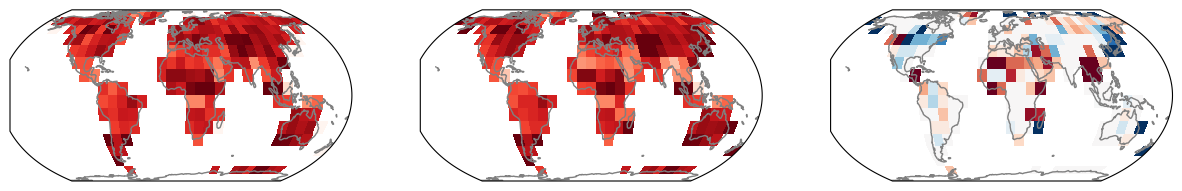

In [52]:
plt.figure(figsize=(15,5))

ax=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,obsaccuracy,vmin=0,vmax=1,cmap='Reds',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

ax=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,1-obsnull,vmin=0,vmax=1,cmap='Reds',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

ax=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,obsaccuracy-(1-obsnull),vmin=-0.2,vmax=0.2,cmap="RdBu_r",transform=ccrs.PlateCarree())

ax.coastlines(color='gray')

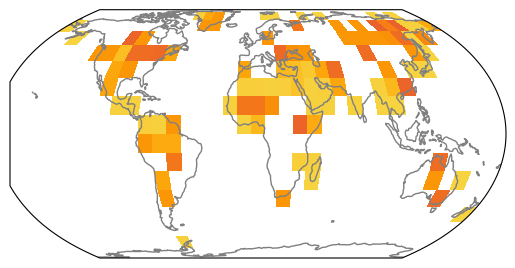

In [53]:
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,obsfirstpositive,vmin=-0.5,vmax=3,cmap='inferno_r',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

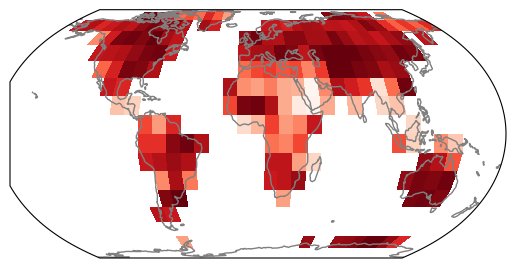

In [54]:
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,baseline_percentile,cmap='Reds',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

In [55]:
# select a gridpoint

latsel = 40
lonsel = 240

metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

if len(filelist)!=0:
    print('models exist, proceeding')

    bestseeds = helpers.get_best_files(filelist,n_best)
    obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

    obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
    obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
    obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)

    obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

    print(bestseeds)
    obsnull[ilat,ilon] = np.mean(obsoutput)

    obspredall = np.empty((3,len(obsinputgmt)))

    for iseed,seed in enumerate(bestseeds):
        # load the model

        loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed_"+str(seed)+".pt"
        cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
        cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
        cnn.to(device)

        with torch.no_grad():
            cnn.eval()
            obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

        obspredall[iseed] = obspred[:,1]


models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 20
[62469869 47621498 18469465]


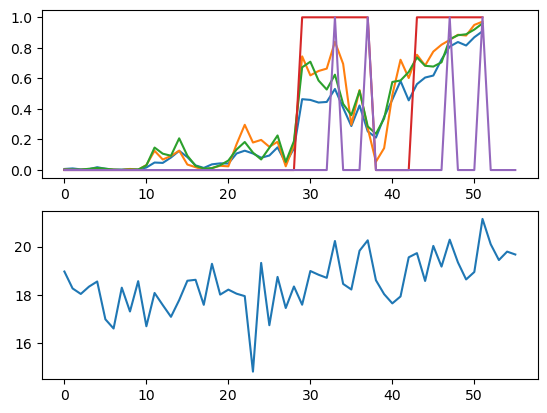

In [56]:
plt.subplot(2,1,1)
plt.plot(np.transpose(obspredall))
plt.plot(obsoutput)
plt.plot(AllObs.recordtemps[10:])
plt.subplot(2,1,2)
plt.plot(AllObs.outputsummer[10:]-273)